# Leaky Modes In The Ghetto 

This is another offering to the anti-resonant gang what they want. Since they can produce such lovely bitmap images it would be a shame not to make philsol work for them. In 2025 LLM's have made outsourcing your PhD to corporations that sell ~~FEM Software~~ consultancy even more ludicrous. 

The important quantity to calculate is the attenuation coefficient. You can do some ~~purturbation theory~~ conservation of energy hand waving to concoct formulas like this:
$$
\alpha = \frac{1}{4}\left[ \frac{\oint_{core} dl \hat n \cdot \vec S}{\int_{core} dA \hat z \cdot \vec S} + c.c \right]
$$
With the hope that even if inaccurate it can capture the important physics. 


# Implementation Steps 
1. Calculate the modes of the waveguide using philsol
2. Calculate the poynting vector $ \vec S $ from the computed fields
3. Compute the integral above numerically
4. Rinse and repeat 

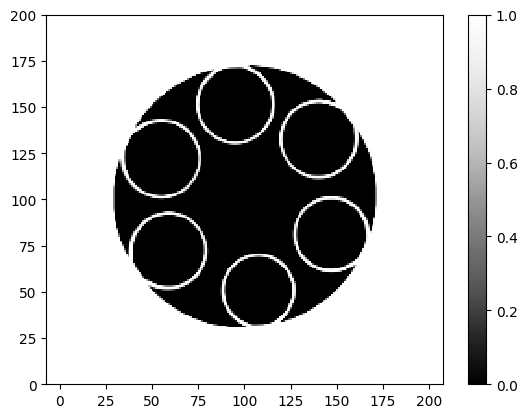

In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as cst

import os 
os.chdir('../')

from philsol.classy import phil_class
os.chdir('examples')

def bmp_to_array(file):
    """
    Convert from a greyscale bpm to a 2D numpy array of normalised floats.
    """
    img = Image.open(file).convert('L')
    img_array = np.asarray(img.getdata(),dtype=np.float64).reshape((img.size[1],img.size[0]))
    img_array /= 255
    
    return img_array 

index_array = bmp_to_array('hollow_core.bmp')

plt.figure()
plt.pcolor(index_array, cmap = 'Greys_r')
plt.axis('equal')
plt.colorbar()

In [3]:
def RefSilica(lam):
    # Selimeir equation for Silica
    
    B1 = 0.6961663
    B2 = 0.4079426
    B3 = 0.8974794
    C1 = 0.0684043**2
    C2 = 0.1162414 **2
    C3 = 9.896161**2
            
    n_square = ( 1  +  B1 * lam**2 / (lam**2 - C1) 
                    +  B2 * lam**2 / (lam**2 - C2) 
                    +  B3 * lam**2 / (lam**2 - C3) )
    
    return n_square**0.5

# Set wavelength and set the size of each pixel  
lam = .6
k = 2. * cst.pi / lam 
dx = 26. / 60.
n = (RefSilica(lam) - 1.) * bmp_to_array('hollow_core.bmp')[:,:,np.newaxis] + 1.   
n = np.repeat(n,3, axis = 2) 
nmodes = 10
beta_guess = k

leakymodes = phil_class(n, k, dx = dx, dy = dx)
leakymodes.build_stuff(matrices=True)
leakymodes.solve_stuff(nmodes, beta_guess, extra_fields=True, poynting_vector=True)

E = leakymodes.E.reshape(leakymodes.Eigs, leakymodes.num_y, leakymodes.num_x, 3)
S = leakymodes.S.reshape(leakymodes.Eigs, leakymodes.num_y, leakymodes.num_x, 3)


Assembling matrix for 40000 grid points...

and we are done (after 4.794889450073242 secs).
Solving eigenmodes on CPU
8.602819442749023 secs later we have the final solution.


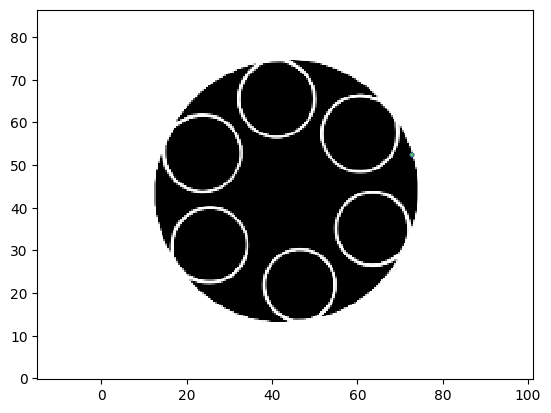

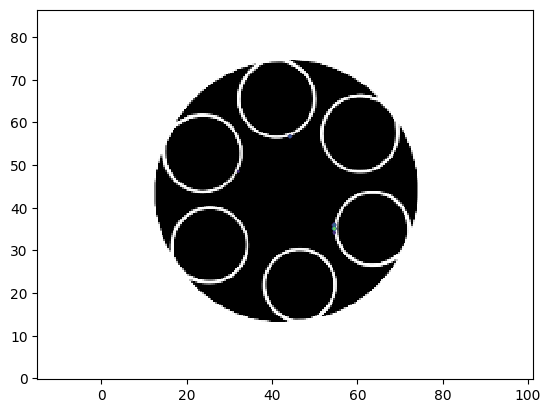

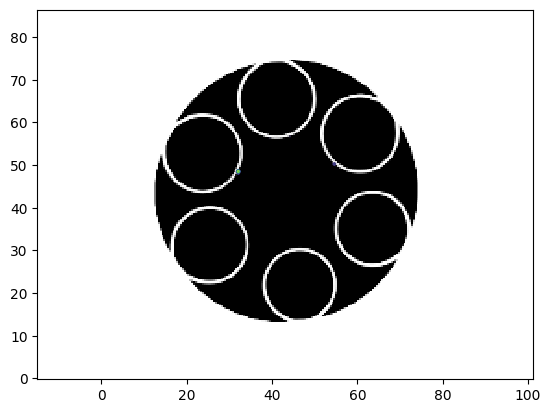

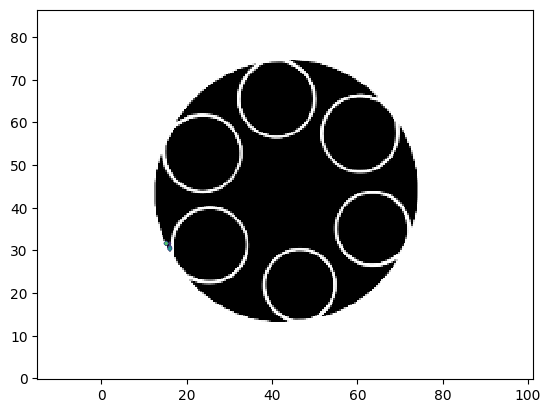

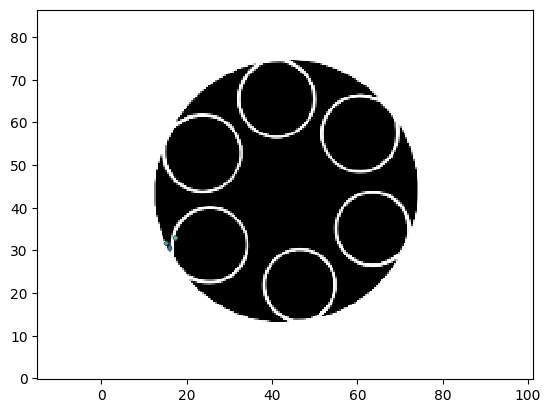

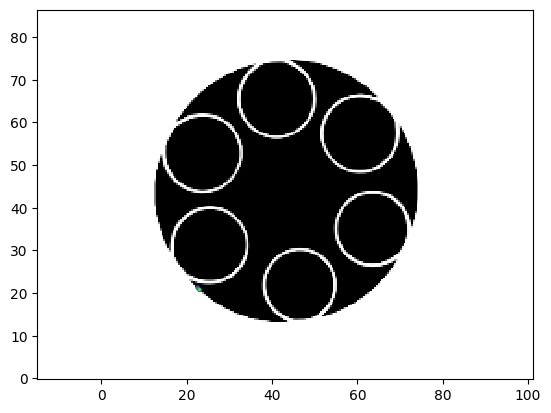

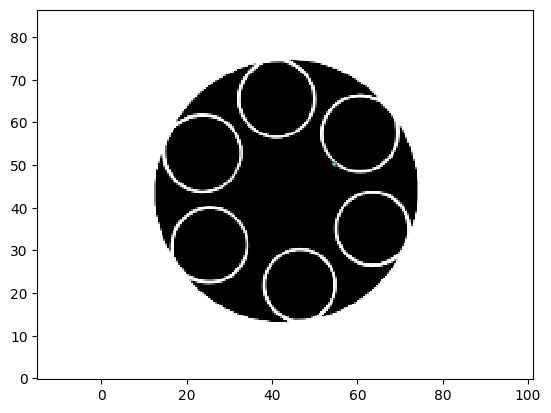

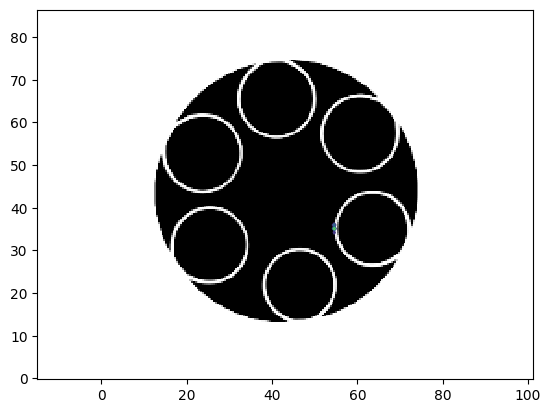

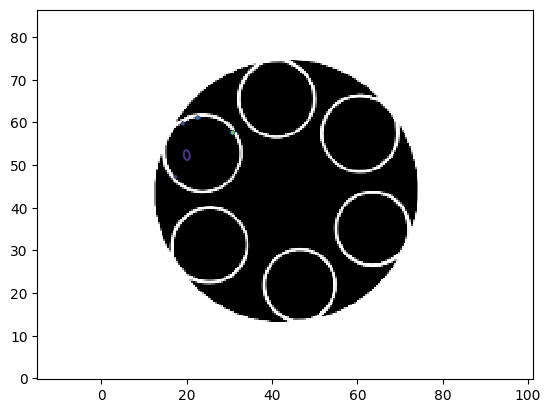

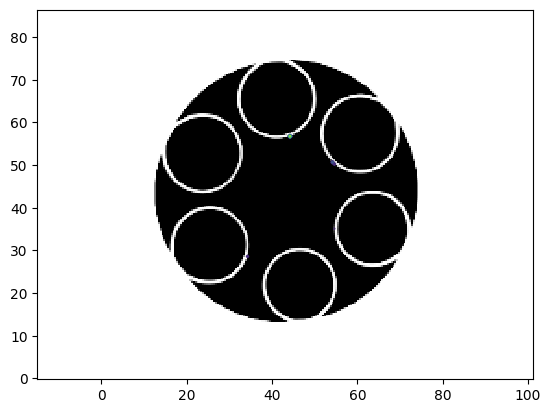

In [ ]:
mode_of_interest = 1
for i in range(leakymodes.Eigs):
    plt.figure()
    plt.pcolormesh(leakymodes.x, leakymodes.y, n[:,:,0].real, cmap = 'Greys_r')
    plt.contour(leakymodes.x, leakymodes.y, abs(S[i,:,:,2]).transpose())
    #plt.pcolormesh(leakymodes.x, leakymodes.y, abs(S[mode_of_interest,:,:,2].transpose()))
    plt.axis('equal')
    plt.show()

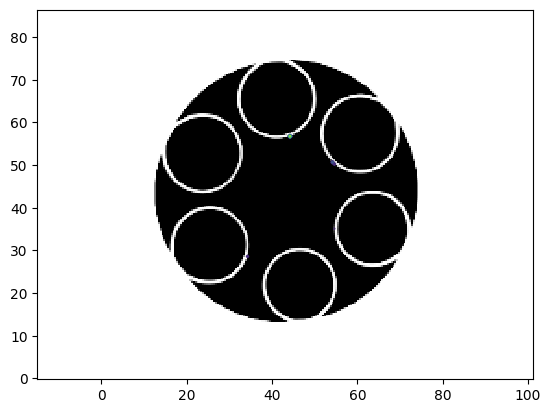

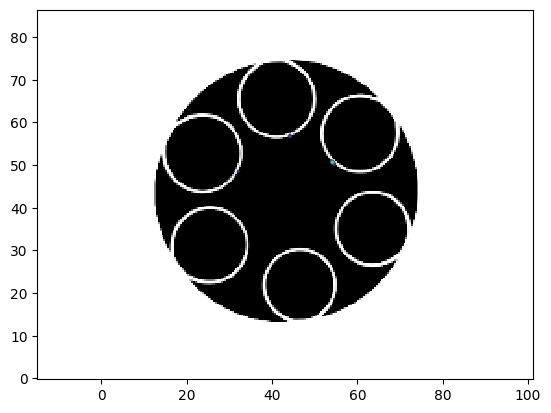

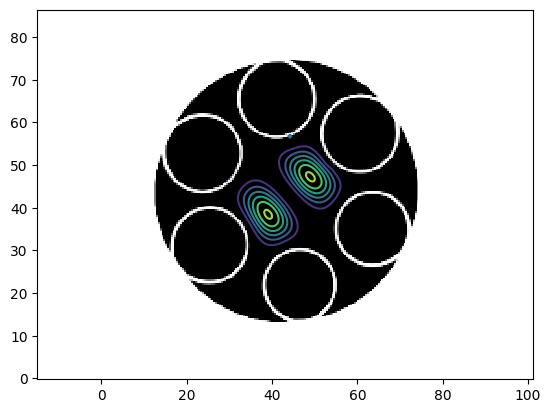

In [5]:
mode_of_interest = 9


plt.figure()
plt.pcolormesh(leakymodes.x, leakymodes.y, n[:,:,0].real, cmap = 'Greys_r')
plt.contour(leakymodes.x, leakymodes.y, abs(S[mode_of_interest,:,:,0]).transpose())
plt.axis('equal')
plt.show()

plt.figure()
plt.pcolormesh(leakymodes.x, leakymodes.y, n[:,:,0].real, cmap = 'Greys_r')
plt.contour(leakymodes.x, leakymodes.y, abs(S[mode_of_interest,:,:,1]).transpose())
plt.axis('equal')
plt.show()

plt.figure()
plt.pcolormesh(leakymodes.x, leakymodes.y, n[:,:,0].real, cmap = 'Greys_r')
plt.contour(leakymodes.x, leakymodes.y, abs(S[mode_of_interest,:,:,2]).transpose())
plt.axis('equal')
plt.show()

Use the following AI generated function to compute the integral

In [6]:
from scipy.interpolate import SmoothBivariateSpline
import scipy.integrate as integrate

def calculate_alpha(phil_instance, mode_index, core_radius: float, center_x: float = None, center_y: float = None) -> np.ndarray:
    """
    Calculate the attenuation coefficient α from the Poynting vector using a fixed core radius.
    
    Uses scipy interpolation to create continuous fields and scipy integration
    for accurate calculation of power flow across the core boundary.
    
    Parameters:
    -----------
    phil_instance : phil_class
        Instance of phil_class containing the computed fields and Poynting vector
        
    core_radius : float
        Radius of the hollow core in the same units as dx and dy
        
    center_x : float, optional
        X-coordinate of the center of the core
        If not provided, uses the center of the grid
        
    center_y : float, optional
        Y-coordinate of the center of the core
        If not provided, uses the center of the grid
    
    Returns:
    --------
    alpha : ndarray
        Attenuation coefficient in dB/m for each mode
    """

    
    if not hasattr(phil_instance, 'S'):
        raise Exception("Poynting vector hasn't been calculated. Run solve_stuff with poynting_vector=True first.")
    

    # Convert grid to polar coordinates
    x = phil_instance.x - .5*max(phil_instance.x)
    y = phil_instance.y - .5*max(phil_instance.y) 

    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    r_grid, theta_grid = np.meshgrid(r, theta, indexing='ij')
    r_grid = r_grid.flatten()
    theta_grid = theta_grid.flatten()

    # Convert vector components (Sz remains unchanged) and turn into interpolators
    S_r = phil_instance.S[mode_index, :, 0] * np.cos(theta_grid) + phil_instance.S[mode_index, :, 1] * np.sin(theta_grid)
    S_r = SmoothBivariateSpline(r_grid, theta_grid, S_r.real)
    S_z = SmoothBivariateSpline(r_grid, theta_grid, phil_instance.S[mode_index, :, 2].real)
    
    radial_integrand = lambda theta : S_r(core_radius, theta)
    P_r = core_radius * integrate.quad(radial_integrand, 0, 2*np.pi)[0]
    P_z = integrate.dblquad(S_z, 0, core_radius, 0, 2*np.pi)[0]

    return abs(P_r / (2.*P_z))
        
core_radius = 60
#core_radius = 10

print(core_radius)
alpha_values = calculate_alpha(leakymodes,mode_of_interest, core_radius=core_radius)

print(alpha_values)

60
0.0024075097957852133
